# Area Score x Lot Score = Location Effectiveness Score

*   12×45 (i,j) base store layout
*   Bir i-j bir ünitenin kapladığı alan
*   Alana (`fixture_center`)a skor atama

1. Defines the store grid directly as `i = 1..45`, `j = 1..12`
2. Keeps blocked/internal wall logic
3. Marks blue fixture-center cells
4. Scores each blue `a(i,j)` using:
   - changing room proximity
   - checkpoint proximity
   - entrance proximity
   - main aisle proximity
   - aisle gradient
   - corner penalty


reminder: r index increases from bottom to top.
c index increases from left to right when facing the fixture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.dpi"] = 140

In [2]:
N_I = 45
N_J = 12

# 0 = aisle/open
# 1 = blocked internal
# 2 = fixture center
grid = np.zeros((N_I, N_J), dtype=int)

def valid(i, j):
    return 1 <= i <= N_I and 1 <= j <= N_J

def mark_block(i, j):
    if valid(i, j):
        grid[i - 1, j - 1] = 1

def mark_fixture(i, j):
    if valid(i, j):
        if grid[i - 1, j - 1] != 1:
            grid[i - 1, j - 1] = 2

def mark_block_rect(i1, i2, j1, j2):
    for i in range(i1, i2 + 1):
        for j in range(j1, j2 + 1):
            mark_block(i, j)

def area(i, j):
    return f"({i},{j})"

mark_block_rect(41, 45, 1, 2)
mark_block_rect(43, 45, 2, 8)   # Kasa
mark_block_rect(13, 34, 10, 12) # Daralan yer
mark_block_rect(11, 12, 1, 2)

#Manuel girdim, askı-raflar
fixture_centers = [
    # SOL
    (2, 1), (4, 1), (6, 1), (8, 1), (10, 2), (13, 2),
    (15, 1), (17, 1), (19, 1), (21, 1), (21, 1), (23, 2),
    (24, 2), (26, 1), (28, 1), (30, 1), (32, 1), (34, 2),
    (35, 2), (37, 1), (39, 1),

    # MASALAR VE KASA ÖNÜ ASKI
    (38, 6), (38, 7),
    (7, 8), (7, 9), (7, 10),
    (18, 3), (18, 4), (18, 5),
    (29, 4), (29, 5),

    # SAĞ
    (1, 11), (2, 12), (4, 12), (6, 12), (7, 12), (9, 12),
    (11, 12), (12, 11), (34,8),

    # Daralan duvarda
    (13, 9), (15, 9), (17, 9), (19, 9), (21, 9),
    (26, 9), (28, 9), (30, 9), (32, 9),
    (35, 10), (35, 11),

    (37, 12), (39, 12),
    (40, 4),
]

for i, j in fixture_centers:
    mark_fixture(i, j)

rows = []
for i in range(1, N_I + 1):
    for j in range(1, N_J + 1):
        val = grid[i - 1, j - 1]
        if val == 0:
            category = "aisle_or_open"
            written_on_image = False
        elif val == 1:
            category = "blocked_internal"
            written_on_image = True
        else:
            category = "fixture_center"
            written_on_image = True

        rows.append({
            "i": i,
            "j": j,
            "area": area(i, j),
            "category": category,
            "written_on_image": written_on_image
        })

df = pd.DataFrame(rows)
df_blocked = df[df["category"] == "blocked_internal"].copy()
df_fixtures = df[df["category"] == "fixture_center"].copy()

print(df["category"].value_counts())

category
aisle_or_open       389
blocked_internal     98
fixture_center       53
Name: count, dtype: int64


Reference logic:
- changing room reference: `a(41,2)`
- checkpoint reference: `a(43,7)`
- entrance reference: `a(1,6)` and `a(1,7)`
- main aisle: the vertical line between `j=6` and `j=7`
- aisle and entrance are dominant
- cornering is negative
- an aisle traffic gradient is added (bunun akademik kaynağını rapora yazacağım!!!!!!!!!!!!!!!!!)

In [3]:
df_effect = df_fixtures.copy()

#biz girdik
changing_room_ref = (41, 2)
checkpoint_ref    = (41, (6.5))
entrance_refs     = [(1, 6), (1, 7)]
main_aisle_j_center = 6.5

main_aisle_i_min = 1
main_aisle_i_max = N_I -5

def euclidean_distance(i1, j1, i2, j2):
    return np.sqrt((i1 - i2) ** 2 + (j1 - j2) ** 2)

def distance_to_entrance(i, j, entrance_points):
    return min(euclidean_distance(i, j, ei, ej) for ei, ej in entrance_points)

def distance_to_main_aisle(i, j, aisle_j=6.5, i_min=1, i_max=40):
    i_proj = min(max(i, i_min), i_max)
    j_proj = aisle_j
    return np.sqrt((i - i_proj) ** 2 + (j - j_proj) ** 2)

def minmax_inverse_score(series):
    smin = series.min()
    smax = series.max()
    if np.isclose(smax, smin):
        return pd.Series(np.ones(len(series)), index=series.index)
    return 1 - (series - smin) / (smax - smin)

df_effect["d_changing"] = df_effect.apply(
    lambda r: euclidean_distance(r["i"], r["j"], changing_room_ref[0], changing_room_ref[1]),
    axis=1
)
df_effect["d_checkpoint"] = df_effect.apply(
    lambda r: euclidean_distance(r["i"], r["j"], checkpoint_ref[0], checkpoint_ref[1]),
    axis=1
)
df_effect["d_entrance"] = df_effect.apply(
    lambda r: distance_to_entrance(r["i"], r["j"], entrance_refs),
    axis=1
)
df_effect["d_main_aisle"] = df_effect.apply(
    lambda r: distance_to_main_aisle(r["i"], r["j"], main_aisle_j_center, main_aisle_i_min, main_aisle_i_max),
    axis=1
)

df_effect["s_changing"]   = minmax_inverse_score(df_effect["d_changing"])
df_effect["s_checkpoint"] = minmax_inverse_score(df_effect["d_checkpoint"])
df_effect["s_entrance"]   = minmax_inverse_score(df_effect["d_entrance"])
df_effect["s_main_aisle"] = minmax_inverse_score(df_effect["d_main_aisle"])

# aisle traffic gradient
df_effect["s_aisle_gradient"] = 1 - ((df_effect["i"] - 1) / (N_I - 1))

# corner penalty
store_center_j = 6.5
df_effect["d_width_center"] = abs(df_effect["j"] - store_center_j)

if df_effect["d_width_center"].max() == df_effect["d_width_center"].min():
    df_effect["corner_width"] = 0.0
else:
    df_effect["corner_width"] = (
        (df_effect["d_width_center"] - df_effect["d_width_center"].min()) /
        (df_effect["d_width_center"].max() - df_effect["d_width_center"].min()))

if df_effect["d_main_aisle"].max() == df_effect["d_main_aisle"].min():
    df_effect["corner_aisle"] = 0.0
else:
    df_effect["corner_aisle"] = df_effect["d_main_aisle"] / df_effect["d_main_aisle"].max()

df_effect["corner_penalty"] = (0.6 * df_effect["corner_width"] +0.4 * df_effect["corner_aisle"])

#!!!!!!!!!!DEĞİŞTİREBİLİRİZ
weights = {
    "s_changing": 0.15,
    "s_checkpoint": 0.20,
    "s_entrance": 0.25,
    "s_main_aisle": 0.20,
    "s_aisle_gradient": 0.25,
    "corner_penalty": 0.05,}

raw_score = (
    weights["s_changing"]       * df_effect["s_changing"] +
    weights["s_checkpoint"]     * df_effect["s_checkpoint"] +
    weights["s_entrance"]       * df_effect["s_entrance"] +
    weights["s_main_aisle"]     * df_effect["s_main_aisle"] +
    weights["s_aisle_gradient"] * df_effect["s_aisle_gradient"] -
    weights["corner_penalty"]   * df_effect["corner_penalty"]
)

#en iyiyi 0.99 yapıyoruz
# en iyiyi 0.99, en düşüğü 0.01 yapıyoruz
if np.isclose(raw_score.max(), raw_score.min()):
    df_effect["area_effectiveness_score"] = 0.99
else:
    df_effect["area_effectiveness_score"] = (
        0.011 + 0.98 * (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())
    )

df_effect["area_effectiveness_score_r"] = df_effect["area_effectiveness_score"].round(3)
df_effect = df_effect.sort_values("area_effectiveness_score", ascending=False).reset_index(drop=True)

df_effect[["area", "i", "j", "area_effectiveness_score_r"]].head(54)

,area,i,j,area_effectiveness_score_r
0,"(7,8)",7,8,0.991
1,"(18,5)",18,5,0.889
2,"(7,9)",7,9,0.851
3,"(38,6)",38,6,0.810
4,"(38,7)",38,7,0.801
5,"(13,9)",13,9,0.794
6,"(29,5)",29,5,0.780
7,"(15,9)",15,9,0.774
8,"(17,9)",17,9,0.754
9,"(18,4)",18,4,0.754


In [4]:
print(df_effect[[
    "area", "i", "j",
    "d_changing", "d_checkpoint", "d_entrance", "d_main_aisle",
    "s_changing", "s_checkpoint", "s_entrance", "s_main_aisle", "s_aisle_gradient","corner_penalty","area_effectiveness_score_r"]].head(54))

       area   i   j  d_changing  d_checkpoint  d_entrance  d_main_aisle  \
0     (7,8)   7   8   34.525353     34.033072    6.082763           1.5   
1    (18,5)  18   5   23.194827     23.048861   17.029386           1.5   
2     (7,9)   7   9   34.713110     34.091788    6.324555           2.5   
3    (38,6)  38   6    5.000000      3.041381   37.000000           0.5   
4    (38,7)  38   7    5.830952      3.041381   37.000000           0.5   
5    (13,9)  13   9   28.861739     28.111386   12.165525           2.5   
6    (29,5)  29   5   12.369317     12.093387   28.017851           1.5   
7    (15,9)  15   9   26.925824     26.119916   14.142136           2.5   
8    (17,9)  17   9   25.000000     24.129857   16.124515           2.5   
9    (18,4)  18   4   23.086793     23.135471   17.117243           2.5   
10   (19,9)  19   9   23.086793     22.141590   18.110770           2.5   
11   (21,9)  21   9   21.189620     20.155644   20.099751           2.5   
12   (34,8)  34   8    9.

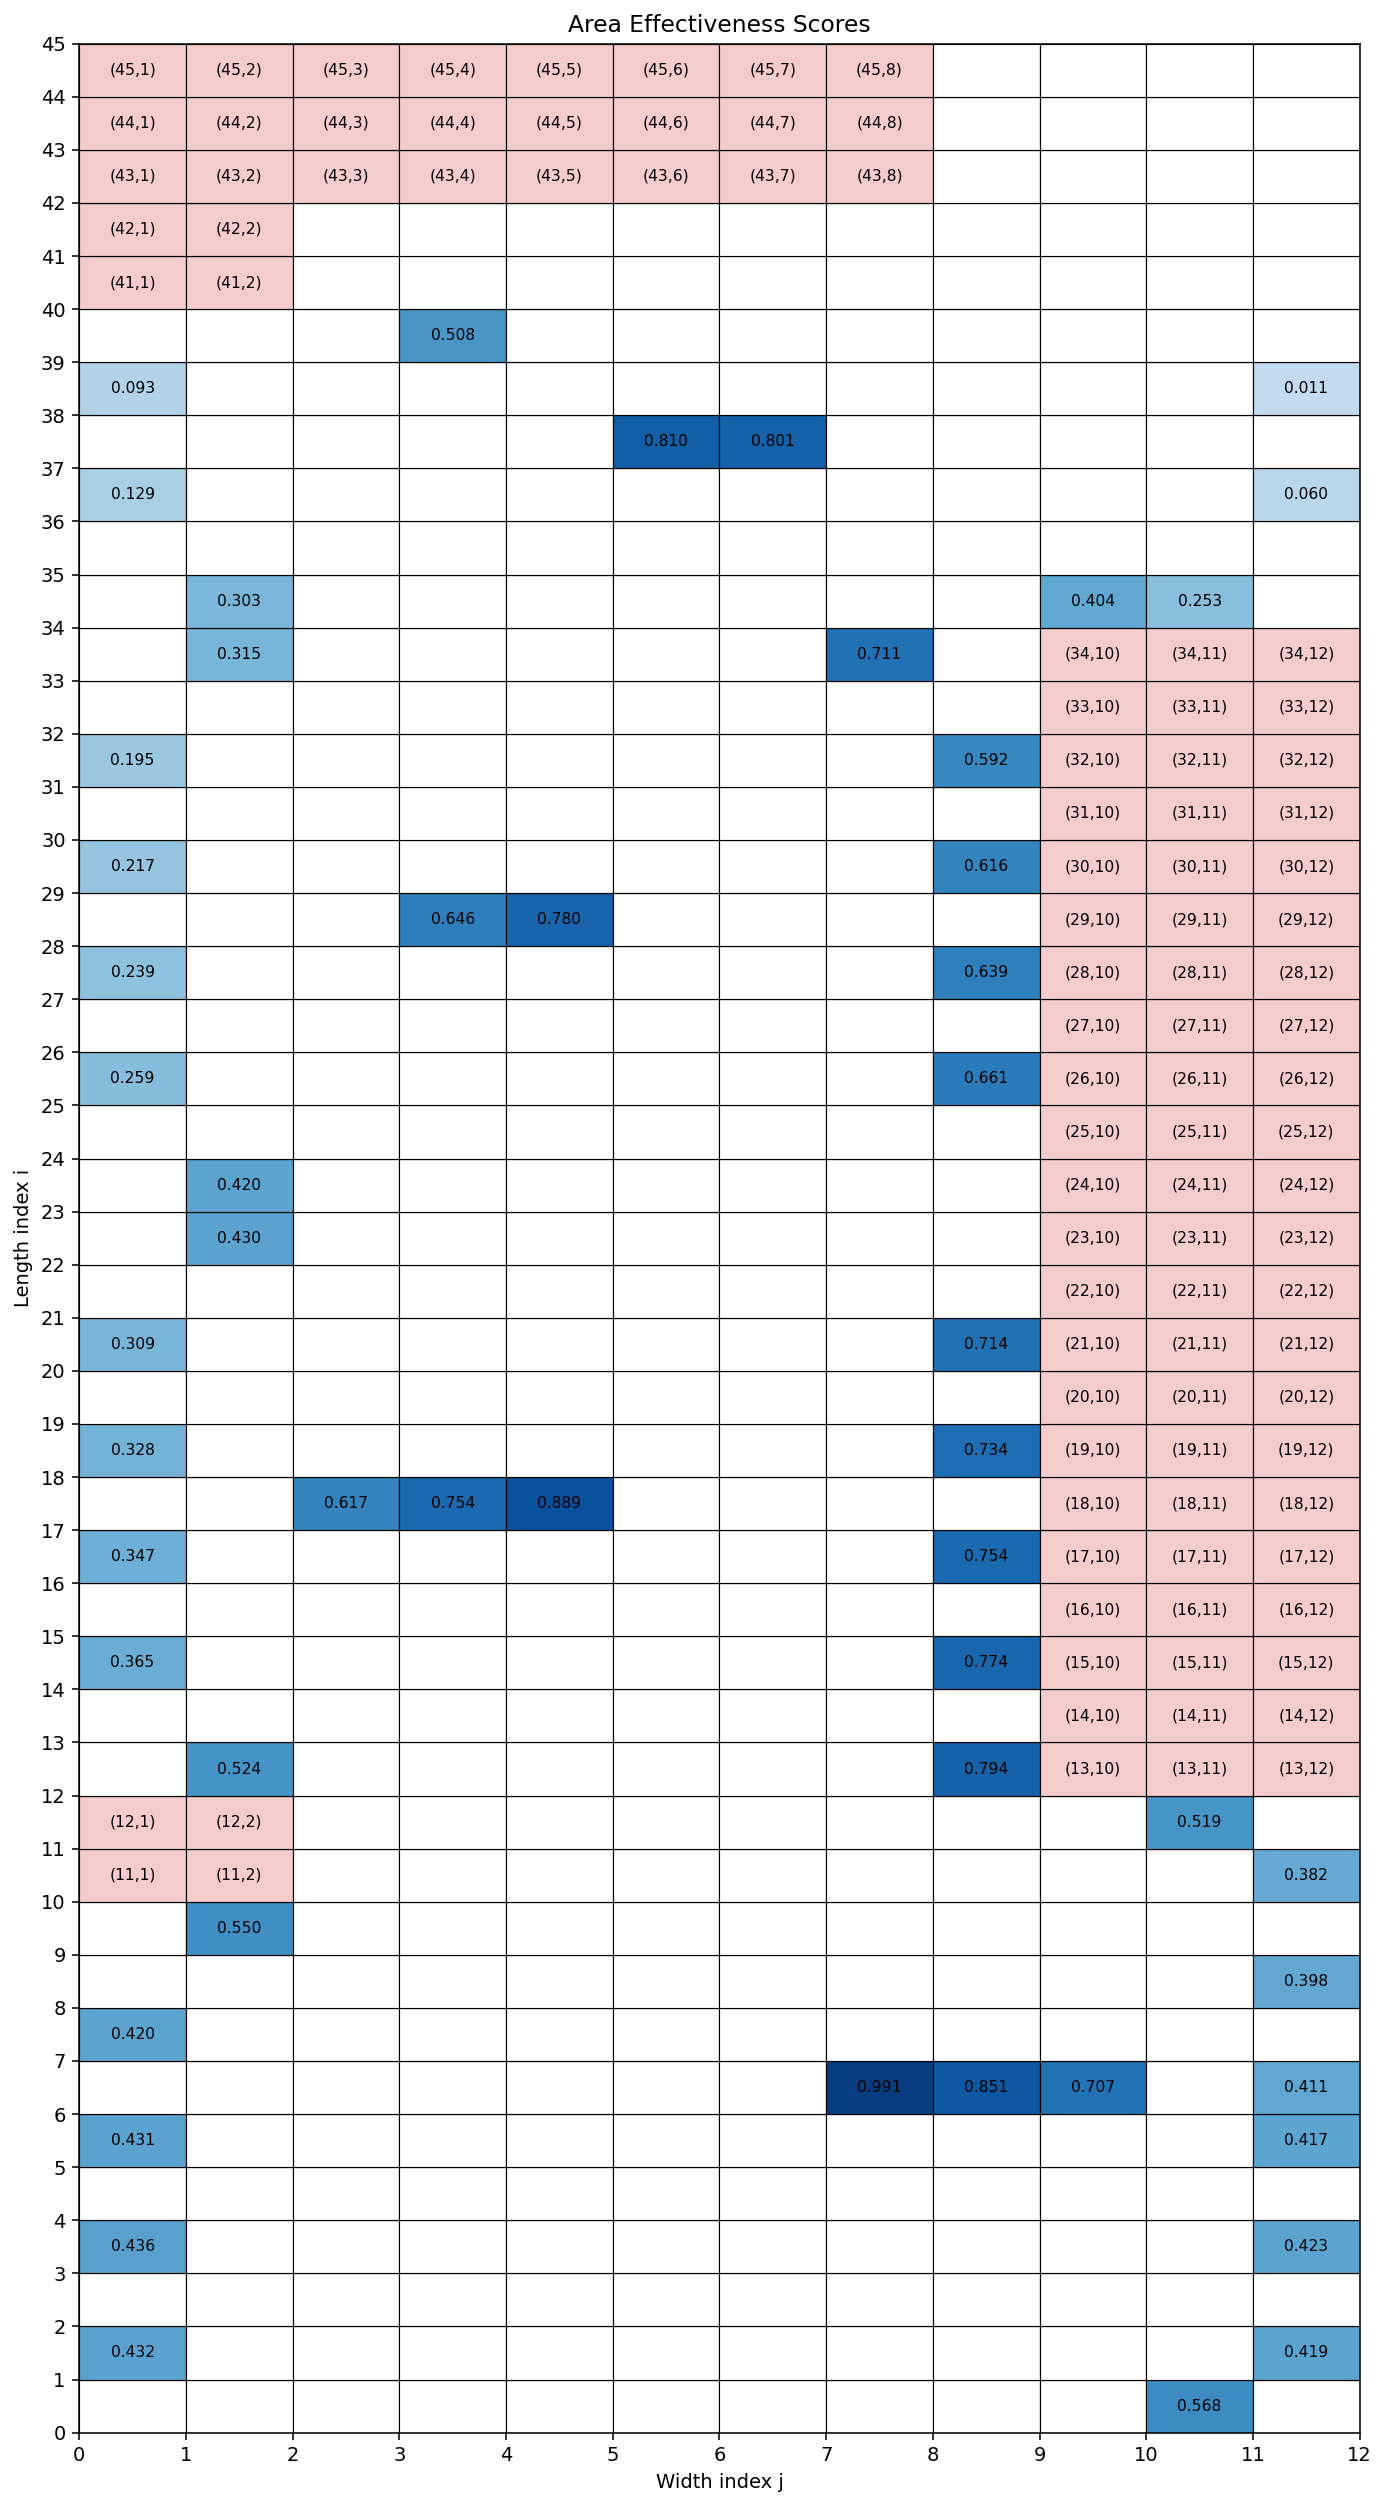

In [5]:
fig, ax = plt.subplots(figsize=(10, 18))

score_map = {(row["i"], row["j"]): row["area_effectiveness_score"] for _, row in df_effect.iterrows()}

for i in range(1, N_I + 1):
    for j in range(1, N_J + 1):
        val = grid[i - 1, j - 1]
        if val == 0:
            face = "white"
        elif val == 1:
            face = "#f4cccc"
        else:
            s = score_map[(i, j)]
            face = plt.cm.Blues(0.25 + 0.70 * s)

        rect = Rectangle((j - 1, i - 1), 1, 1, facecolor=face, edgecolor="black", linewidth=0.6)
        ax.add_patch(rect)

for _, row in df_blocked.iterrows():
    i, j = int(row["i"]), int(row["j"])
    ax.text(j - 0.5, i - 0.5, row["area"], ha="center", va="center", fontsize=8)

for _, row in df_effect.iterrows():
    i, j = int(row["i"]), int(row["j"])
    ax.text(j - 0.5, i - 0.5, f"{row['area_effectiveness_score']:.3f}", ha="center", va="center", fontsize=8)

ax.set_xlim(0, N_J)
ax.set_ylim(0, N_I)
ax.set_xticks(np.arange(0, N_J + 1, 1))
ax.set_yticks(np.arange(0, N_I + 1, 1))
ax.set_xlabel("Width index j")
ax.set_ylabel("Length index i")
ax.set_title("Area Effectiveness Scores")
plt.tight_layout()
plt.show()

NameError: name 'a' is not defined

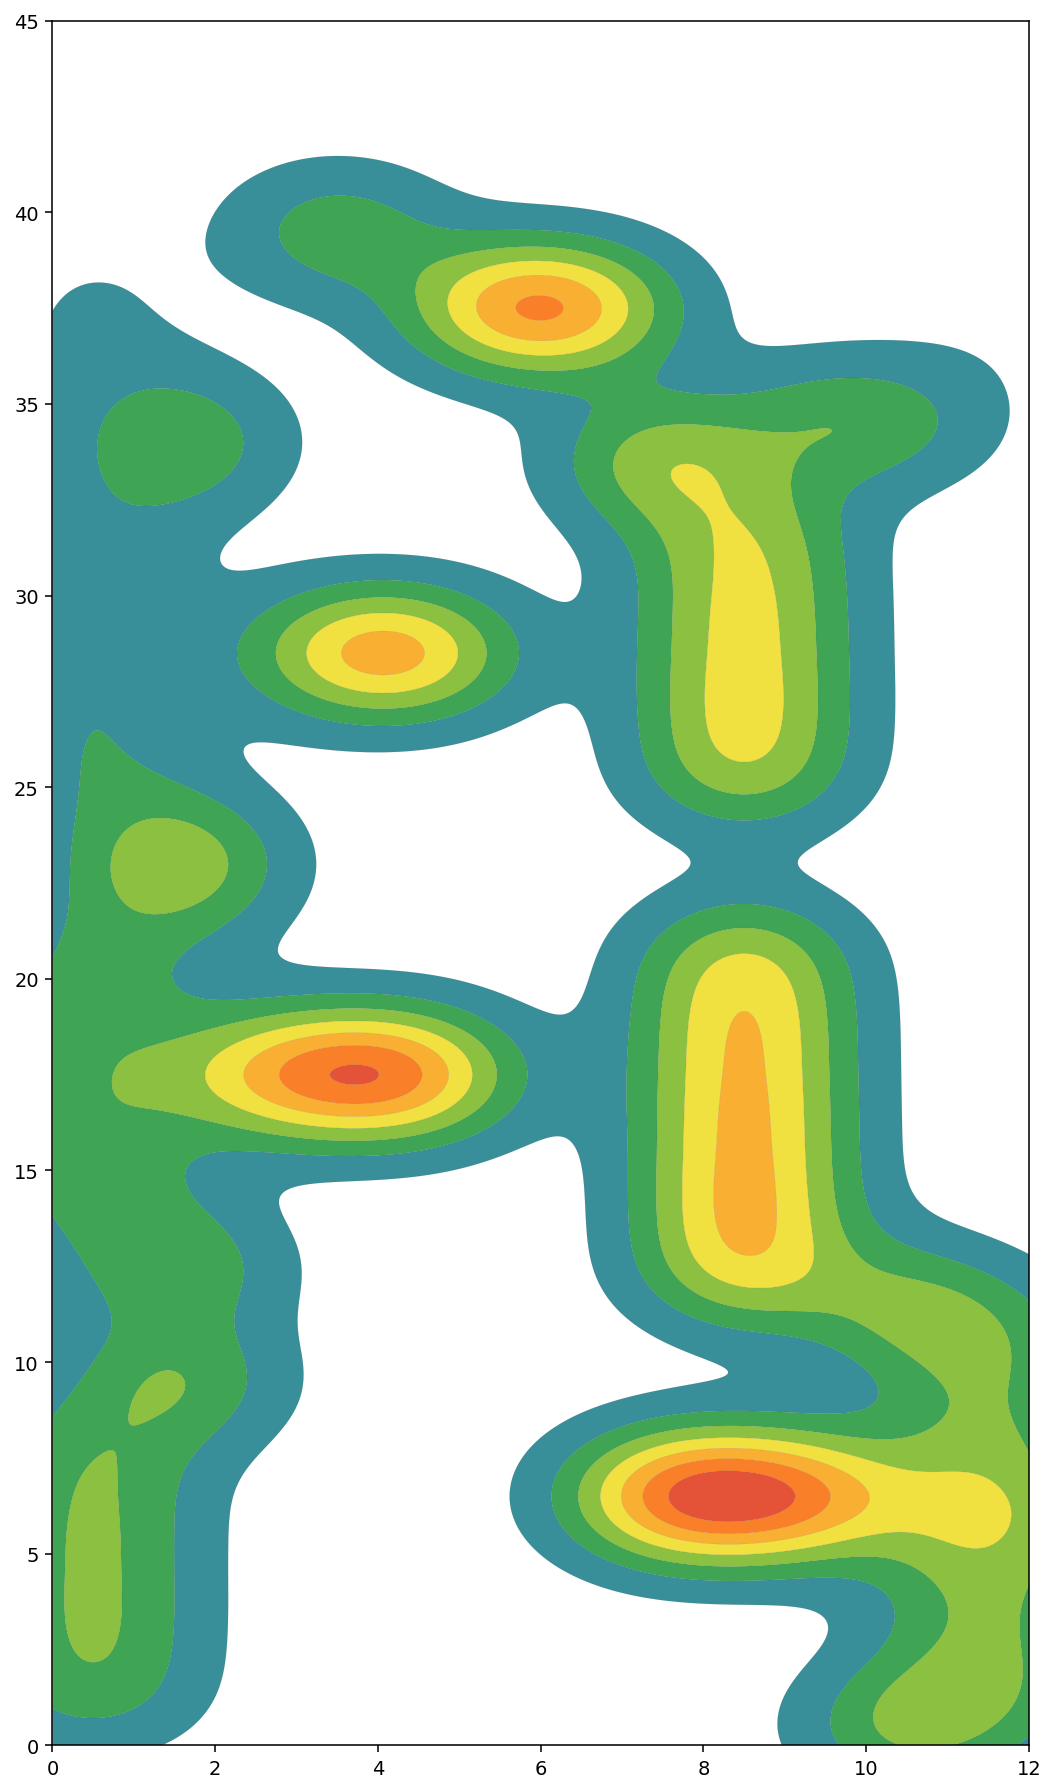

In [8]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

x = np.linspace(0, N_J, 500)
y = np.linspace(0, N_I, 1200)
X, Y = np.meshgrid(x, y)

heat = np.zeros_like(X, dtype=float)
sigma_x = 0.95
sigma_y = 1.25

#RENK GEÇİŞLERİNİ YAPAN YER
for _, row in df_effect.iterrows():
    cx = row["b"] - 0.5
    cy = row["a"] - 0.5
    amp = row["area_effectiveness_score"]

    gaussian = amp * np.exp(-(((X - cx) ** 2) / (2 * sigma_x ** 2) + ((Y - cy) ** 2) / (2 * sigma_y ** 2)))
    heat += gaussian

if not np.isclose(heat.max(), heat.min()):
    heat = (heat - heat.min()) / (heat.max() - heat.min())
else:
    heat[:] = 0.0

heat_cmap = LinearSegmentedColormap.from_list("retail_heat",["#1f77b4", "#2ca02c", "#f1dd2b", "#ff7f0e", "#d62728"],N=256)
levels = np.linspace(0.08, 1.0, 8)
fig, ax = plt.subplots(figsize=(9, 16))
ax.set_facecolor("white")

cf = ax.contourf(
    X, Y, heat,
    levels=levels,
    cmap=heat_cmap,
    alpha=0.90,
    antialiased=True)

ax.contour(
    X, Y, heat,
    levels=levels,
    colors="k",
    linewidths=0.18,
    alpha=0.20)

for i in range(1, N_I + 1):
    for j in range(1, N_J + 1):
        val = grid[a - 1, b - 1]

        # if blocked, draw later
        if val == 1:
            continue

        # no-heat cells explicitly white
        rect_bg = Rectangle(
            (b - 1, a - 1), 1, 1,
            facecolor="white" if heat[i - 1, min(j - 1, heat.shape[1]-1)] < levels[0] else "none",
            edgecolor="#6f6f6f",
            linewidth=0.45,
            alpha=0.55)
        ax.add_patch(rect_bg)

for _, row in df_blocked.iterrows():
    rect = Rectangle(
        (row["b"] - 1, row["a"] - 1), 1, 1,
        facecolor="#2b2b2b",
        edgecolor="black",
        linewidth=0.75,
        alpha=0.8
    )
    ax.add_patch(rect)

#MOBİLYALARIN KISMI
for _, row in df_effect.iterrows():
    rect = Rectangle(
        (row["b"] - 1, row["a"] - 1), 1, 1,
        facecolor="none",
        linewidth=0.8,
        edgecolor="white",

        linestyle="--",
        alpha=0.80)
    ax.add_patch(rect)

#SCORELARI MOBİLYA ÜSTÜNE YAZDIRMA
for _, row in df_effect.iterrows():
    ax.text(
        row["b"] - 0.5,
        row["a"] - 0.5,
        f"{row['area_effectiveness_score']:.3f}",
        ha="center",
        va="center",
        fontsize=8,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=0.2))

ref_style = dict(s=46, c="red", edgecolors="none", linewidths=0.7, zorder=6)
ax.scatter([5.5, 6.5], [0.5, 0.5], **ref_style)
ax.text(6.0, 1.10, "Entrance",color="darkred", fontsize=8, ha="center", va="bottom",bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2))

ax.scatter([1.5], [40.5], **ref_style)
ax.text(1.9, 40.7, "Changing room ref",color="darkred", fontsize=8, ha="left", va="bottom", bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2))

ax.scatter([6.5], [42.5], **ref_style)
ax.text(6.8, 42.7, "Checkpoint ref", color="darkred", fontsize=8, ha="left", va="bottom", bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2))

ax.plot([6, 6], [0, N_I], color="black", linewidth=1.6, alpha=0.75, linestyle=":")
ax.text(6.2, N_I / 2, "Main aisle", color="black", fontsize=8, rotation=90, ha="left", va="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0))

#MANUEL DUVAR ÇİZME YERİ!!!!!!!!!!
def draw_wall(ax, x1, y1, x2, y2, lw=3.2):
    ax.plot(
        [x1, x2],
        [y1, y2],
        color="black",
        linewidth=lw,
        solid_capstyle="round",
        zorder=10)

#BURASI İSTEDİĞİMİZ DUVAR ÇİZGİ YERLERİ GİRME
draw_wall(ax, 0, 34, (2.2), 34)
draw_wall(ax, 8, 34, 12, 34)
draw_wall(ax, (0.8), 23, (2.2), 23)
draw_wall(ax, 8, 12, 12, 12)
draw_wall(ax, 2, 40, 2, 45)
draw_wall(ax, 1, 40, 5, 40)
draw_wall(ax, 7, 34, 12, 34)


legend_handles = [
    Patch(facecolor="#2b2b2b", edgecolor="black", label="No product display"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
           markeredgecolor="black", markersize=7, label="Reference point"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.6, label="Main aisle"),]

leg = ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=7,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    title_fontsize=8)

# colorbar GÖSTERGE
cbar = fig.colorbar(cf, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Heat intensity / area effectiveness", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_xlim(0, N_J)
ax.set_ylim(0, N_I)
ax.set_xticks(np.arange(0, N_J + 1, 1))
ax.set_yticks(np.arange(0, N_I + 1, 1))
ax.set_xlabel("Width index j", fontsize=9)
ax.set_ylabel("Length index i", fontsize=9)
ax.set_title("Retail-Style Smooth Heatmap on (a,b) Layout", fontsize=11, pad=10)

#ÇERÇEVE
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("black")

plt.tight_layout(pad=0.8)
plt.show()

In [7]:
# Rename old grid columns if needed
if "b" not in df_effect.columns and "j" in df_effect.columns:
    df_effect = df_effect.rename(columns={"i": "a", "j": "b"})

if "b" not in df_blocked.columns and "j" in df_blocked.columns:
    df_blocked = df_blocked.rename(columns={"i": "a", "j": "b"})

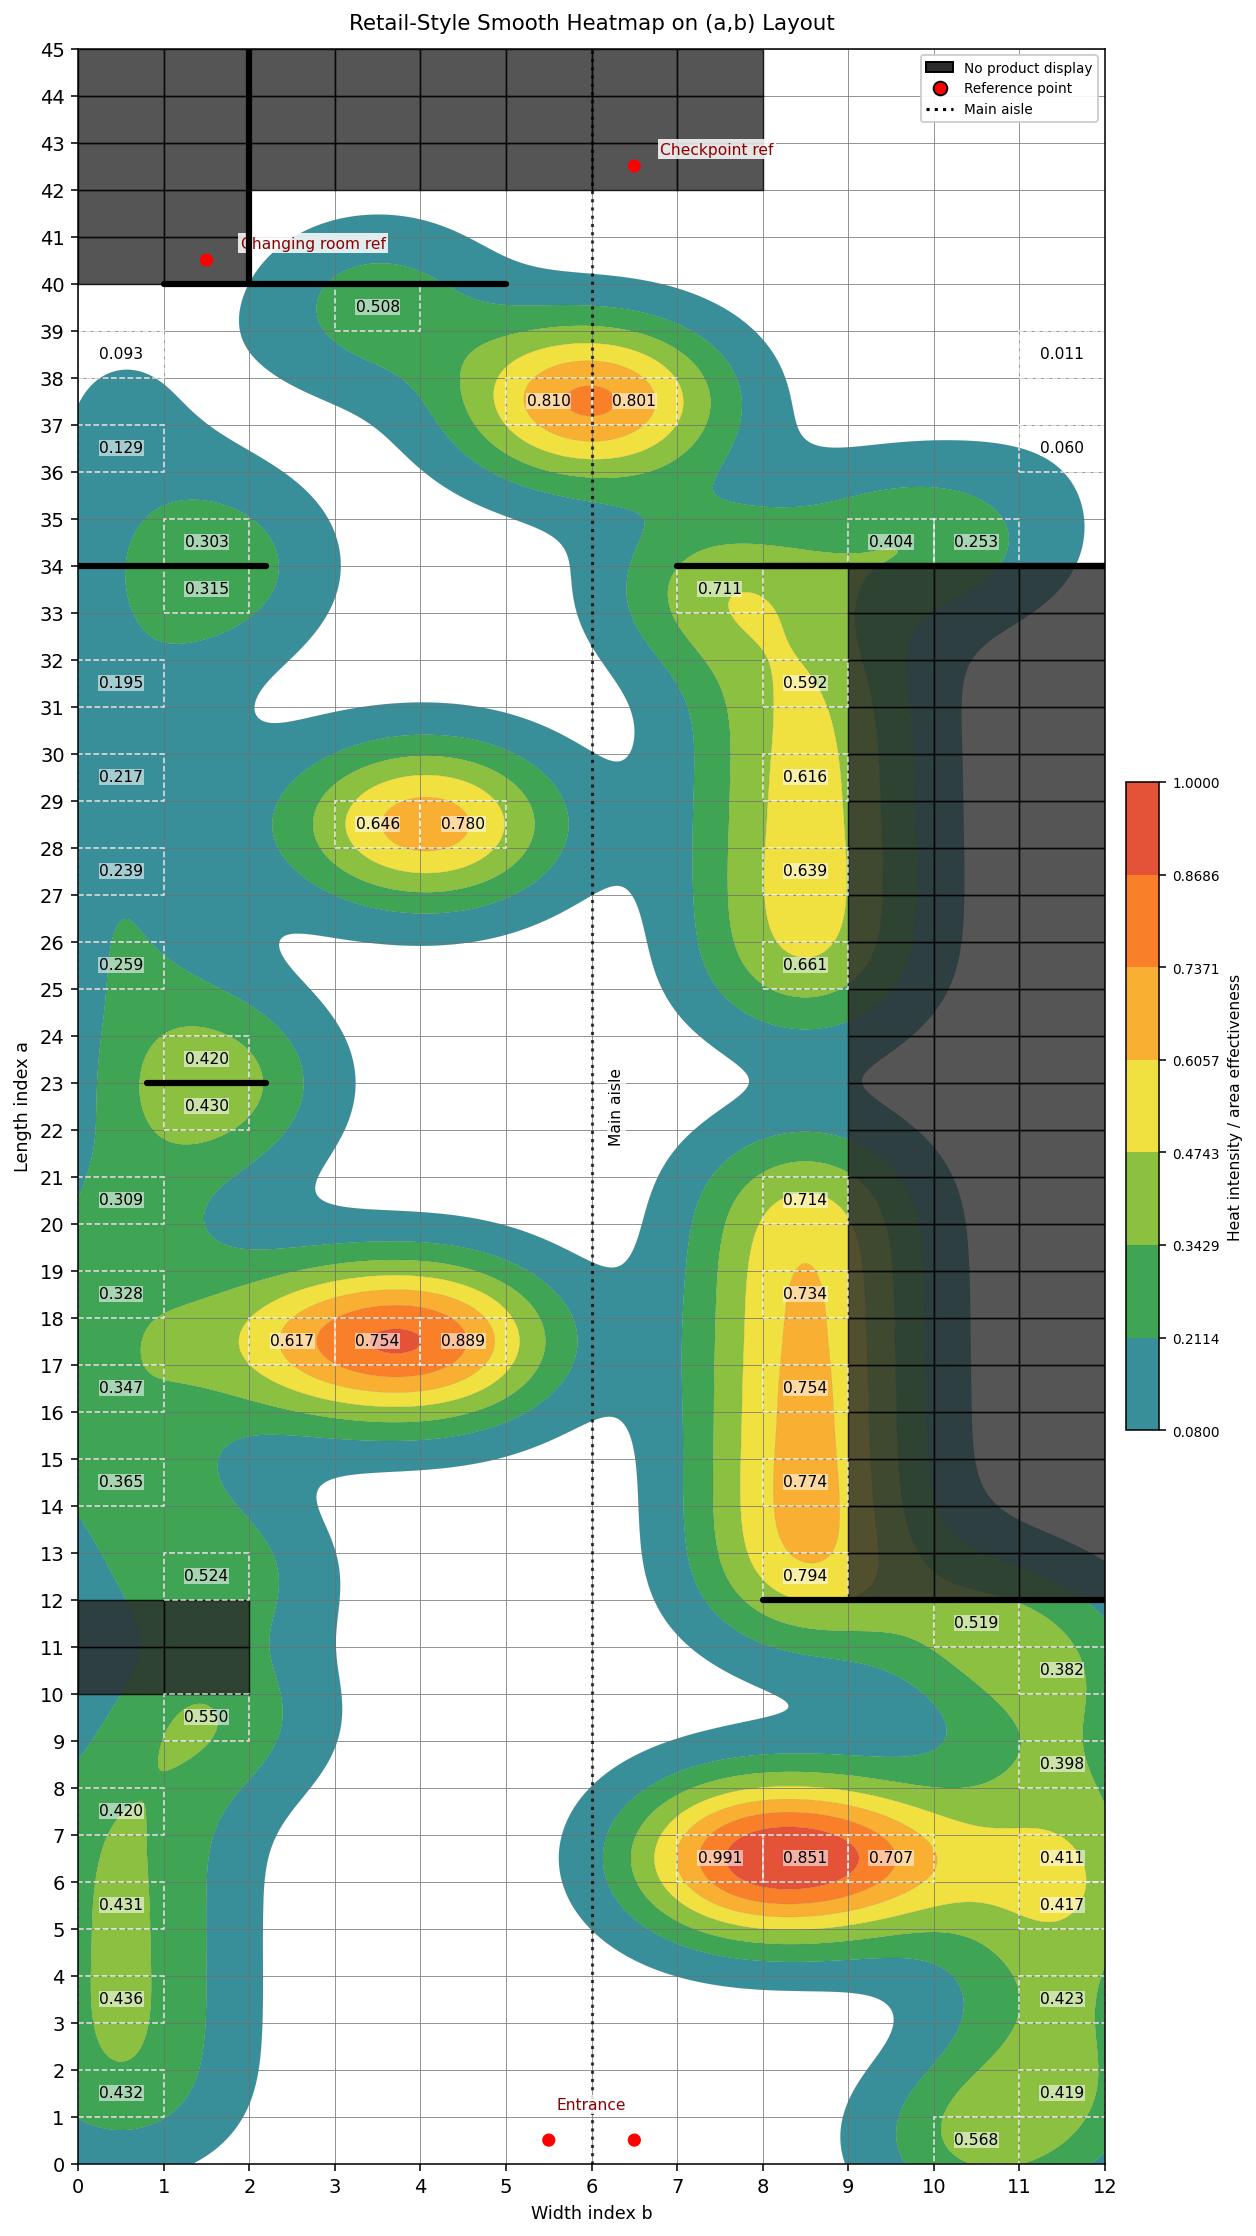

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, N_J, 500)
y = np.linspace(0, N_I, 1200)
X, Y = np.meshgrid(x, y)

heat = np.zeros_like(X, dtype=float)
sigma_x = 0.95
sigma_y = 1.25

# RENK GEÇİŞLERİNİ YAPAN YER
for _, row in df_effect.iterrows():
    cx = row["b"] - 0.5
    cy = row["a"] - 0.5
    amp = row["area_effectiveness_score"]

    gaussian = amp * np.exp(
        -(((X - cx) ** 2) / (2 * sigma_x ** 2)
          + ((Y - cy) ** 2) / (2 * sigma_y ** 2))
    )
    heat += gaussian

if not np.isclose(heat.max(), heat.min()):
    heat = (heat - heat.min()) / (heat.max() - heat.min())
else:
    heat[:] = 0.0

heat_cmap = LinearSegmentedColormap.from_list(
    "retail_heat",
    ["#1f77b4", "#2ca02c", "#f1dd2b", "#ff7f0e", "#d62728"],
    N=256
)

levels = np.linspace(0.08, 1.0, 8)

fig, ax = plt.subplots(figsize=(9, 16))
ax.set_facecolor("white")

cf = ax.contourf(
    X, Y, heat,
    levels=levels,
    cmap=heat_cmap,
    alpha=0.90,
    antialiased=True
)

ax.contour(
    X, Y, heat,
    levels=levels,
    colors="k",
    linewidths=0.18,
    alpha=0.20
)

# GRID CELLS
for a in range(1, N_I + 1):
    for b in range(1, N_J + 1):

        val = grid[a - 1, b - 1]

        if val == 1:
            continue

        rect_bg = Rectangle(
            (b - 1, a - 1), 1, 1,
            facecolor="white" if heat[a - 1, min(b - 1, heat.shape[1] - 1)] < levels[0] else "none",
            edgecolor="#6f6f6f",
            linewidth=0.45,
            alpha=0.55
        )
        ax.add_patch(rect_bg)

# BLOCKED CELLS
for _, row in df_blocked.iterrows():
    rect = Rectangle(
        (row["b"] - 1, row["a"] - 1), 1, 1,
        facecolor="#2b2b2b",
        edgecolor="black",
        linewidth=0.75,
        alpha=0.8
    )
    ax.add_patch(rect)

# MOBİLYALARIN KISMI
for _, row in df_effect.iterrows():
    rect = Rectangle(
        (row["b"] - 1, row["a"] - 1), 1, 1,
        facecolor="none",
        linewidth=0.8,
        edgecolor="white",
        linestyle="--",
        alpha=0.80
    )
    ax.add_patch(rect)

# SCORELARI MOBİLYA ÜSTÜNE YAZDIRMA
for _, row in df_effect.iterrows():
    ax.text(
        row["b"] - 0.5,
        row["a"] - 0.5,
        f"{row['area_effectiveness_score']:.3f}",
        ha="center",
        va="center",
        fontsize=8,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=0.2)
    )

# REFERENCE POINTS
ref_style = dict(s=46, c="red", edgecolors="none", linewidths=0.7, zorder=6)

ax.scatter([5.5, 6.5], [0.5, 0.5], **ref_style)
ax.text(
    6.0, 1.10, "Entrance",
    color="darkred",
    fontsize=8,
    ha="center",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2)
)

ax.scatter([1.5], [40.5], **ref_style)
ax.text(
    1.9, 40.7, "Changing room ref",
    color="darkred",
    fontsize=8,
    ha="left",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2)
)

ax.scatter([6.5], [42.5], **ref_style)
ax.text(
    6.8, 42.7, "Checkpoint ref",
    color="darkred",
    fontsize=8,
    ha="left",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2)
)

# MAIN AISLE
ax.plot(
    [6, 6], [0, N_I],
    color="black",
    linewidth=1.6,
    alpha=0.75,
    linestyle=":"
)

ax.text(
    6.2, N_I / 2, "Main aisle",
    color="black",
    fontsize=8,
    rotation=90,
    ha="left",
    va="center",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0)
)

# MANUEL DUVAR ÇİZME YERİ
def draw_wall(ax, x1, y1, x2, y2, lw=3.2):
    ax.plot(
        [x1, x2],
        [y1, y2],
        color="black",
        linewidth=lw,
        solid_capstyle="round",
        zorder=10
    )

# DUVAR ÇİZGİLERİ
draw_wall(ax, 0, 34, 2.2, 34)
draw_wall(ax, 8, 34, 12, 34)
draw_wall(ax, 0.8, 23, 2.2, 23)
draw_wall(ax, 8, 12, 12, 12)
draw_wall(ax, 2, 40, 2, 45)
draw_wall(ax, 1, 40, 5, 40)
draw_wall(ax, 7, 34, 12, 34)

# LEGEND
legend_handles = [
    Patch(facecolor="#2b2b2b", edgecolor="black", label="No product display"),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=7,
        label="Reference point"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=1.6,
        label="Main aisle"
    ),
]

leg = ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=7,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    title_fontsize=8
)

# COLORBAR
cbar = fig.colorbar(cf, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Heat intensity / area effectiveness", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# AXES
ax.set_xlim(0, N_J)
ax.set_ylim(0, N_I)

ax.set_xticks(np.arange(0, N_J + 1, 1))
ax.set_yticks(np.arange(0, N_I + 1, 1))

ax.set_xlabel("Width index b", fontsize=9)
ax.set_ylabel("Length index a", fontsize=9)
ax.set_title("Retail-Style Smooth Heatmap on (a,b) Layout", fontsize=11, pad=10)

# ÇERÇEVE
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("black")

plt.tight_layout(pad=0.8)
plt.show()

In [10]:
#İSTEDİĞİMİZ A(İ,J) KONTORL
check_cells = ["(37,1)", "(39,1)", "(37,12)", "(38,12)", "(39,12)"]

df_effect[df_effect["area"].isin(check_cells)][[
    "area",
    "s_changing",
    "s_checkpoint",
    "s_entrance",
    "s_main_aisle",
    "s_aisle_gradient",
    "corner_penalty",
    "area_effectiveness_score"
]].sort_values("area")


,area,s_changing,s_checkpoint,s_entrance,s_main_aisle,s_aisle_gradient,corner_penalty,area_effectiveness_score
49,"(37,1)",0.951320,0.890624,0.077192,0.0,0.181818,1.0,0.128651
51,"(37,12)",0.779840,0.890624,0.077192,0.0,0.181818,1.0,0.059807
50,"(39,1)",1.000000,0.915874,0.020647,0.0,0.136364,1.0,0.093461
52,"(39,12)",0.794604,0.915874,0.020647,0.0,0.136364,1.0,0.011000


In [12]:

#fixture=mobilya tipi
fixtures = {}

def A(i, j):
    return (i, j)

def add_fixture(cells, fixture_type, r_max, c_max, family_rule="all_clothing", **extra):
    for cell in cells:
        fixtures[cell] = {
            "fixture_type": fixture_type,
            "r_max": r_max,
            "c_max": c_max,
            "family_rule": family_rule,
            **extra
        }

# 2) FIXTURE DEFINITIONS
# Small wall hanger: 6 dizili + 1 facing olan gümüş-beyazlar
add_fixture(
    cells=[
        A(2,1), A(4,1), A(6,1), A(8,1),
        A(10,2), A(1,11), A(12,11), A(2,12),
        A(4,12), A(9,12), A(11,12),
        A(13,2), A(15,1), A(17,1),
        A(19,1), A(21,1), A(40,4), A(37,12), A(39,12),],
    fixture_type="wall_hanger_small",
    r_max=3,
    c_max=7,
    family_rule="hanger_split",
    row2_modes={
        "hanging_cols": [1,2,3,4,5,6],
        "front_facing_cols": [7],})

# Large wall hanger: 10 dizili + 1 facing olan açık ahşaplar
add_fixture(
    cells=[
        A(13,9), A(15,9), A(17,9), A(19,9),
        A(28,9), A(30,9),A(26,1),A(28,1),A(32,1),A(30,1),
        A(32,9), A(37,1), A(39,1),],
    fixture_type="wall_hanger_large",
    r_max=3,
    c_max=11,
    family_rule="hanger_split",
    row2_modes={
        "hanging_cols": list(range(1,11)),
        "front_facing_cols": [11],})

# Shelf 4x4: Türettik, facingi yok ve sadece clothing alacak. Türettiğimiz için saydığımız mağaza sayısından fazla kapasiteye sebep oluyor.
add_fixture(
    cells=[A(35,11), A(35,10)],
    fixture_type="shelf_4x4",
    r_max=4,
    c_max=4,
    family_rule="all_clothing")

# Small upright: Kasaya doğru odaları bölen ince beyaz-gümüşler
add_fixture(
    cells=[A(34,2), A(34,8), A(35,2), A(23,2), A(24,2)],
    fixture_type="upright_small_3col",
    r_max=3,
    c_max=3,
    family_rule="hanger_split")

# Tables: Giriş sağ: 1 tane yüksek 2x5 ahşap, 2 tane diz 2x4 ahşap.    İkinci oda sol: 1 tnae yüksek 2x6 beyaz-gümüş, 2 dix 1x5
add_fixture([A(7,9)], "table_2x5", r_max=2, c_max=5, family_rule="all_clothing")
add_fixture([A(7,8), A(7,10)], "table_2x4", r_max=2, c_max=4, family_rule="all_clothing")
add_fixture([A(18,3), A(18,5)], "table_1x5_low", r_max=1, c_max=5, family_rule="all_clothing")
add_fixture([A(18,4)], "table_2x6_high", r_max=2, c_max=6, family_rule="all_clothing")
add_fixture([A(29,4), A(29,5)], "table_1x5", r_max=1, c_max=5, family_rule="all_clothing")

# --- Single facing hang
add_fixture(
    [A(7,12), A(6,12), A(21,9), A(26,9)],
    "single_facing_1x1",
    r_max=1,
    c_max=1,
    family_rule="all_clothing",
    mode="front_facing"
)

# --- Double-end facing linear
add_fixture(
    [A(38,6), A(38,7)],
    "double_facing_linear_1x10",
    r_max=1,
    c_max=10,
    family_rule="all_clothing",
    row1_modes={
        "front_facing_cols": [1, 10],
        "normal_cols": [2,3,4,5,6,7,8,9]
    }
)

# =========================================================
# 3) EXPAND FIXTURES INTO LOTS
# Updated capacity rule:
# - wall_hanger_small and wall_hanger_large:
#   row 2 keeps original c_max for clothing
#   rows 1 and 3 each have only 2 columns for accessories
# - upright_small_3col:
#   keep full 3 columns on rows 1,2,3
# - 4x4 shelves:
#   all rows and columns are clothing lots
# - tables:
#   all rows and columns are clothing lots
# =========================================================
def expand_fixture_lots(A_i, A_j, meta):
    lots = []

    r_max = meta["r_max"]
    c_max = meta["c_max"]
    family_rule = meta["family_rule"]
    fixture_type = meta["fixture_type"]

    # wall_hanger_small / wall_hanger_large
    if fixture_type in ["wall_hanger_small", "wall_hanger_large"]:
        # row 1 accessory, 2 columns
        for c in range(1, 3):
            lots.append({
                "A_i": A_i,
                "A_j": A_j,
                "fixture_type": fixture_type,
                "r": 1,
                "c": c,
                "mode": "normal",
                "product_family": "accessory"
            })

        # row 2 clothing, full c_max
        row2_modes = meta.get("row2_modes", {})
        for c in range(1, c_max + 1):
            mode = "normal"
            if c in row2_modes.get("front_facing_cols", []):
                mode = "front_facing"
            elif c in row2_modes.get("hanging_cols", []):
                mode = "hanging"

            lots.append({
                "A_i": A_i,
                "A_j": A_j,
                "fixture_type": fixture_type,
                "r": 2,
                "c": c,
                "mode": mode,
                "product_family": "clothing"
            })

        # row 3 accessory, 2 columns
        for c in range(1, 3):
            lots.append({
                "A_i": A_i,
                "A_j": A_j,
                "fixture_type": fixture_type,
                "r": 3,
                "c": c,
                "mode": "normal",
                "product_family": "accessory"
            })

        return lots

    # upright_small_3col: keep old full structure
    if fixture_type == "upright_small_3col":
        for r in [1, 2, 3]:
            for c in range(1, c_max + 1):
                product_family = "clothing" if r == 2 else "accessory"
                lots.append({
                    "A_i": A_i,
                    "A_j": A_j,
                    "fixture_type": fixture_type,
                    "r": r,
                    "c": c,
                    "mode": "normal",
                    "product_family": product_family
                })
        return lots

    # general logic for the rest
    for r in range(1, r_max + 1):
        for c in range(1, c_max + 1):
            mode = "normal"
            product_family = "clothing"

            if r == 2 and "row2_modes" in meta:
                if c in meta["row2_modes"].get("front_facing_cols", []):
                    mode = "front_facing"
                elif c in meta["row2_modes"].get("hanging_cols", []):
                    mode = "hanging"

            if r == 1 and "row1_modes" in meta:
                if c in meta["row1_modes"].get("front_facing_cols", []):
                    mode = "front_facing"

            if "mode" in meta:
                mode = meta["mode"]

            if family_rule == "all_clothing":
                product_family = "clothing"

            lots.append({
                "A_i": A_i,
                "A_j": A_j,
                "fixture_type": fixture_type,
                "r": r,
                "c": c,
                "mode": mode,
                "product_family": product_family
            })

    return lots

# expand all fixtures
all_lots = []
for (A_i, A_j), meta in fixtures.items():
    all_lots.extend(expand_fixture_lots(A_i, A_j, meta))

lots_df = pd.DataFrame(all_lots)

print("Assigned fixture cells:", len(fixtures))
print("Unique fixture families:", fixture_cells_df['fixture_type'].nunique() if 'fixture_cells_df' in globals() else len(pd.DataFrame([{'fixture_type':v['fixture_type']} for v in fixtures.values()]).drop_duplicates()))
print("Total lots:", len(lots_df))
print("\nLots by product family:")
print(lots_df["product_family"].value_counts())

print("\nLots by fixture type:")
print(lots_df.groupby("fixture_type").size())

print("\nSample:")
print(lots_df.head(20))



Assigned fixture cells: 53
Unique fixture families: 11
Total lots: 563

Lots by product family:
product_family
clothing     405
accessory    158
Name: count, dtype: int64

Lots by fixture type:
fixture_type
double_facing_linear_1x10     20
shelf_4x4                     32
single_facing_1x1              4
table_1x5                     10
table_1x5_low                 10
table_2x4                     16
table_2x5                     10
table_2x6_high                12
upright_small_3col            45
wall_hanger_large            195
wall_hanger_small            209
dtype: int64

Sample:
    A_i  A_j       fixture_type  r  c          mode product_family
0     2    1  wall_hanger_small  1  1        normal      accessory
1     2    1  wall_hanger_small  1  2        normal      accessory
2     2    1  wall_hanger_small  2  1       hanging       clothing
3     2    1  wall_hanger_small  2  2       hanging       clothing
4     2    1  wall_hanger_small  2  3       hanging       clothing
5     

In [13]:
#Scorelar
def centrality_score(c, c_max, edge_min=0.70, center_max=1.00):
    if c_max == 1:
        return center_max

    mid = (c_max + 1) / 2
    max_dist = max(abs(1 - mid), abs(c_max - mid))
    dist = abs(c - mid)
    return center_max - (center_max - edge_min) * (dist / max_dist)


def shelf_vertical_score(r, r_max):
    if r_max == 1:
        return 1.00
    elif r_max == 2:
        return {1: 0.90, 2: 1.00}[r]
    elif r_max == 3:
        return {1: 0.70, 2: 1.00, 3: 0.85}[r]
    elif r_max == 4:
        return {1: 0.70, 2: 0.95, 3: 1.00, 4: 0.80}[r]
    else:
        mid = (r_max + 1) / 2
        max_dist = max(abs(1 - mid), abs(r_max - mid))
        dist = abs(r - mid)
        return 1.00 - 0.30 * (dist / max_dist)


def table_row_score(r, r_max):
    if r_max == 1:
        return 1.00
    elif r_max == 2:
        return {1: 0.95, 2: 1.00}[r]
    else:
        return shelf_vertical_score(r, r_max)


# L_type SCORING FUNCTION
def L_score(fixture_type, r, c, mode, r_max, c_max):
    # 1) HANGER TYPES
    if fixture_type in ["wall_hanger_small", "wall_hanger_large", "upright_small_3col"]:
        if r == 2:
            cent = centrality_score(c, c_max, edge_min=0.75, center_max=1.00)

            if mode == "front_facing":
                return 1.25 * cent
            elif mode == "hanging":
                return 1.00 * cent
            else:
                return 0.95 * cent

        elif r == 1:
            cent = centrality_score(c, c_max, edge_min=0.72, center_max=0.95)
            return 0.65 * cent

        elif r == 3:
            cent = centrality_score(c, c_max, edge_min=0.72, center_max=0.95)
            return 0.82 * cent

    # 2) SINGLE FRONT-FACING
    elif fixture_type == "single_facing_1x1":
        return 1.35

    # 3) DOUBLE-END-FACING LINEAR
    elif fixture_type == "double_facing_linear_1x10":
        if mode == "front_facing":
            return 1.20
        else:
            cent = centrality_score(c, c_max, edge_min=0.80, center_max=1.00)
            return 0.95 * cent
    # 4) TABLES
    elif fixture_type in ["table_2x5", "table_2x4", "table_1x5_low", "table_2x6_high", "table_1x5"]:
        row_part = table_row_score(r, r_max)
        col_part = centrality_score(c, c_max, edge_min=0.82, center_max=1.00)

    # Deduce table attractiveness from number of rows
    # r_max = 2  -> belly level
    # r_max = 1  -> knee level
        if r_max == 2:
          base = 1.08   # belly level
        elif r_max == 1:
          base = 0.82   # knee level
        else:
          base = 0.95   # fallback

        return base * row_part * col_part


    # 5) 4x4 SHELF
    elif fixture_type == "shelf_4x4":
        row_part = shelf_vertical_score(r, r_max)
        col_part = centrality_score(c, c_max, edge_min=0.78, center_max=1.00)
        return 0.92 * row_part * col_part

    # fallback
    else:
        row_part = shelf_vertical_score(r, r_max)
        col_part = centrality_score(c, c_max, edge_min=0.80, center_max=1.00)
        return row_part * col_part


def get_fixture_meta(A_i, A_j):
    return fixtures[(A_i, A_j)]


lots_df["L_type_score"] = lots_df.apply(
    lambda row: L_score(
        fixture_type=row["fixture_type"],
        r=row["r"],
        c=row["c"],
        mode=row["mode"],
        r_max=get_fixture_meta(row["A_i"], row["A_j"])["r_max"],
        c_max=get_fixture_meta(row["A_i"], row["A_j"])["c_max"],
    ),
    axis=1
)

print(lots_df[[
    "A_i", "A_j", "fixture_type", "r", "c", "mode",
    "product_family", "L_type_score"
]].head(54))

# FIX: this used to be a 3-row placeholder stub (A_i in [2,4,6] only),
# which left A_score as NaN for every other lot in the store. Use the real
# area effectiveness scores computed above in df_effect instead.
A_df = df_effect[["a", "b", "area_effectiveness_score_r"]].rename(
    columns={"a": "A_i", "b": "A_j", "area_effectiveness_score_r": "A_score"}
)

lots_df = lots_df.merge(A_df, on=["A_i", "A_j"], how="left")

_missing = lots_df["A_score"].isna().sum()
if _missing:
    raise ValueError(
        f"{_missing} lots have no matching A_score after merge -- "
        "check that every fixture A(i,j) in `fixtures` also appears in df_effect."
    )
print(f"A_score merged for all {len(lots_df)} lots, 0 missing.")


####ASIL SALEBİLİTY COMPOUNDDD
# Raw combined score
lots_df["S_score_raw"] = lots_df["A_score"] * lots_df["L_type_score"]

# Rescale to 0.01 - 0.99
s_min = lots_df["S_score_raw"].min()
s_max = lots_df["S_score_raw"].max()

if np.isclose(s_min, s_max):
    lots_df["S_score"] = 0.90
else:
    lots_df["S_score"] = 0.01 + 0.98 * (
        (lots_df["S_score_raw"] - s_min) / (s_max - s_min)
    )

lots_df["S_score"] = lots_df["S_score"].round(3)

    A_i  A_j       fixture_type  r  c          mode product_family  \
0     2    1  wall_hanger_small  1  1        normal      accessory   
1     2    1  wall_hanger_small  1  2        normal      accessory   
2     2    1  wall_hanger_small  2  1       hanging       clothing   
3     2    1  wall_hanger_small  2  2       hanging       clothing   
4     2    1  wall_hanger_small  2  3       hanging       clothing   
5     2    1  wall_hanger_small  2  4       hanging       clothing   
6     2    1  wall_hanger_small  2  5       hanging       clothing   
7     2    1  wall_hanger_small  2  6       hanging       clothing   
8     2    1  wall_hanger_small  2  7  front_facing       clothing   
9     2    1  wall_hanger_small  3  1        normal      accessory   
10    2    1  wall_hanger_small  3  2        normal      accessory   
11    4    1  wall_hanger_small  1  1        normal      accessory   
12    4    1  wall_hanger_small  1  2        normal      accessory   
13    4    1  wall_h

In [14]:
#masada öndeki hiza daha değerli olsun
def table_row_score(r, r_max):
    if r_max == 1:
        return 0.90
    elif r_max == 2:
        # one row slightly stronger than the other
        return {1: 0.7, 2: 0.9}[r]
    else:
        return shelf_vertical_score(r, r_max)

#yer ve skor
print(table_1x5_cells)
print(table_row_score(1, 1))
print(table_row_score(1, 2))

[(29, 4), (29, 5)]
0.9
0.7


In [15]:
# UNIQUE FIXTURE FAMILIES AND UNIQUE L_types

# one row per assigned fixture cell A(i,j)
fixture_cells_df = (
    pd.DataFrame(
        [{"A_i": i, "A_j": j, **meta} for (i, j), meta in fixtures.items()]
    )
    .sort_values(["fixture_type", "A_i", "A_j"])
    .reset_index(drop=True)
)

# fixture family summary
fixture_family_df = (
    fixture_cells_df[["fixture_type", "r_max", "c_max", "family_rule"]]
    .drop_duplicates()
    .sort_values(["fixture_type", "r_max", "c_max"])
    .reset_index(drop=True)
)

print("Number of assigned fixture cells:", len(fixture_cells_df))
print("Number of unique fixture families:", fixture_family_df['fixture_type'].nunique())
display(fixture_family_df)

# unique L_types = unique slot structures actually generated in lots_df
L_types_df = (
    lots_df[
        ["fixture_type", "r", "c", "mode", "product_family", "L_type_score"]
    ]
    .drop_duplicates()
    .sort_values(["fixture_type", "product_family", "r", "c", "mode"])
    .reset_index(drop=True)
)

L_types_df.insert(0, "L_type_ID", range(1, len(L_types_df) + 1))

print("Number of unique fixture-slot L_types:", len(L_types_df))
display(L_types_df.head(30))



Number of assigned fixture cells: 53
Number of unique fixture families: 11


,fixture_type,r_max,c_max,family_rule
0,double_facing_linear_1x10,1,10,all_clothing
1,shelf_4x4,4,4,all_clothing
2,single_facing_1x1,1,1,all_clothing
3,table_1x5,1,5,all_clothing
4,table_1x5_low,1,5,all_clothing
5,table_2x4,2,4,all_clothing
6,table_2x5,2,5,all_clothing
7,table_2x6_high,2,6,all_clothing
8,upright_small_3col,3,3,hanger_split
9,wall_hanger_large,3,11,hanger_split


Number of unique fixture-slot L_types: 102


,L_type_ID,fixture_type,r,c,mode,product_family,L_type_score
0,1,double_facing_linear_1x10,1,1,front_facing,clothing,1.200000
1,2,double_facing_linear_1x10,1,2,normal,clothing,0.802222
2,3,double_facing_linear_1x10,1,3,normal,clothing,0.844444
3,4,double_facing_linear_1x10,1,4,normal,clothing,0.886667
4,5,double_facing_linear_1x10,1,5,normal,clothing,0.928889
5,6,double_facing_linear_1x10,1,6,normal,clothing,0.928889
6,7,double_facing_linear_1x10,1,7,normal,clothing,0.886667
7,8,double_facing_linear_1x10,1,8,normal,clothing,0.844444
8,9,double_facing_linear_1x10,1,9,normal,clothing,0.802222
9,10,double_facing_linear_1x10,1,10,front_facing,clothing,1.200000


In [16]:
# LOT COUNTS / CAPACITY CELLS

# lot capacity by assigned fixture cell A(i,j)
capacity_cells_df = (
    lots_df.groupby(["A_i", "A_j", "fixture_type", "product_family"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

if "clothing" not in capacity_cells_df.columns:
    capacity_cells_df["clothing"] = 0
if "accessory" not in capacity_cells_df.columns:
    capacity_cells_df["accessory"] = 0

capacity_cells_df["total_lots"] = (
    capacity_cells_df["clothing"] + capacity_cells_df["accessory"]
)

capacity_cells_df = capacity_cells_df.sort_values(
    ["fixture_type", "A_i", "A_j"]
).reset_index(drop=True)

print("Fixture-cell lot capacities:")
display(capacity_cells_df)

# summary by fixture family
capacity_by_type_df = (
    capacity_cells_df.groupby("fixture_type")[["clothing", "accessory", "total_lots"]]
    .sum()
    .reset_index()
)

fixture_counts_df = (
    fixture_cells_df.groupby("fixture_type")
    .size()
    .reset_index(name="n_fixture_cells")
)

capacity_by_type_df = capacity_by_type_df.merge(
    fixture_counts_df, on="fixture_type", how="left"
)

capacity_by_type_df["avg_lots_per_fixture_cell"] = (
    capacity_by_type_df["total_lots"] / capacity_by_type_df["n_fixture_cells"]
)

print("Lot summary by fixture family:")
display(capacity_by_type_df)

print("Total clothing lots in store:", int(capacity_cells_df["clothing"].sum()))
print("Total accessory lots in store:", int(capacity_cells_df["accessory"].sum()))
print("Total lots in store:", int(capacity_cells_df["total_lots"].sum()))



Fixture-cell lot capacities:


product_family,A_i,A_j,fixture_type,accessory,clothing,total_lots
0,38,6,double_facing_linear_1x10,0,10,10
1,38,7,double_facing_linear_1x10,0,10,10
2,35,10,shelf_4x4,0,16,16
3,35,11,shelf_4x4,0,16,16
4,6,12,single_facing_1x1,0,1,1
5,7,12,single_facing_1x1,0,1,1
6,21,9,single_facing_1x1,0,1,1
7,26,9,single_facing_1x1,0,1,1
8,29,4,table_1x5,0,5,5
9,29,5,table_1x5,0,5,5


Lot summary by fixture family:


,fixture_type,clothing,accessory,total_lots,n_fixture_cells,avg_lots_per_fixture_cell
0,double_facing_linear_1x10,20,0,20,2,10.0
1,shelf_4x4,32,0,32,2,16.0
2,single_facing_1x1,4,0,4,4,1.0
3,table_1x5,10,0,10,2,5.0
4,table_1x5_low,10,0,10,2,5.0
5,table_2x4,16,0,16,2,8.0
6,table_2x5,10,0,10,1,10.0
7,table_2x6_high,12,0,12,1,12.0
8,upright_small_3col,15,30,45,5,9.0
9,wall_hanger_large,143,52,195,13,15.0


Total clothing lots in store: 405
Total accessory lots in store: 158
Total lots in store: 563


In [17]:
export_filename = "../../data/02_interim/A_scores.xlsx"

export_cols = [
    "a", "b", "area",
    "area_effectiveness_score",
    "area_effectiveness_score_r",
    "d_changing", "d_checkpoint", "d_entrance", "d_main_aisle",
    "s_changing", "s_checkpoint", "s_entrance", "s_main_aisle",
    "s_aisle_gradient", "corner_penalty",
]

df_effect_export = df_effect[export_cols].copy()
df_effect_export.to_excel(export_filename, index=False)

print(f"Exported {len(df_effect_export)} A(a,b) scores to {export_filename}")

Exported 53 A(a,b) scores to A_scores.xlsx


## Export fixture geometry + grid (for Step 4 visualization)

The CP-SAT notebook (Step 4) and the planogram viz only need the fixture layout metadata (`A_i`, `A_j`, `fixture_type`, `max_r`, `max_c`) and the store grid — not the full scoring detail in `A_scores.xlsx`. This cell exports that subset once so downstream steps don't need to recompute the grid/fixtures dict from scratch.

In [ ]:
import json
from pathlib import Path

# One row per assigned fixture cell, with a stable fix_idx for the viz layer.
fixtures_export = (
    fixture_cells_df
    .sort_values(["fixture_type", "A_i", "A_j"])
    .reset_index(drop=True)
)

fixture_grid_payload = {
    "N_I": N_I,
    "N_J": N_J,
    "grid": grid.tolist(),
    "fixtures": [
        {
            "A_ij": f"A({int(row.A_i)},{int(row.A_j)})",
            "A_i": int(row.A_i),
            "A_j": int(row.A_j),
            "fixture_type": row.fixture_type,
            "fix_idx": idx,
            "max_r": int(row.r_max),
            "max_c": int(row.c_max),
        }
        for idx, row in fixtures_export.iterrows()
    ],
}

out_path = Path("../../data/02_interim/fixture_grid.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(fixture_grid_payload, f)

print(f"Exported {len(fixture_grid_payload['fixtures'])} fixtures and "
      f"{N_I}x{N_J} grid to {out_path}")